# AI-Powered Customer Support Agent
### Memory · RAG · LangChain ≥1.2.0 · LangGraph ≥0.2 · Groq

---

## APIs Required
| Secret Name | Purpose | Required |
|---|---|---|
| `GROQ_API_KEY` | Groq LLM — `llama-3.1-8b-instant` (agent) + `llama-3.3-70b-versatile` (fallback) | **YES** |
| `TAVILY_API_KEY` | Web-search tool for the ReAct agent | Optional |

> Set both under **Colab → Tools → Secrets** before running.

---

## Free / Open-Source Stack
| Layer | Library | Notes |
|---|---|---|
| Agent | `langgraph>=0.2` `create_react_agent` + `MemorySaver` | No paid infra |
| LLM | `langchain-groq>=0.2` | Free tier via Groq |
| Tools | `langchain-core>=0.3` `@tool` decorator | |
| Web search | `langchain-community>=0.3` `TavilySearchResults` | Optional |
| Text splitter | `langchain-text-splitters>=0.3` | |
| Vector DB (RAG) | `faiss-cpu` | Fully local |
| Vector DB (Memory) | `faiss-cpu` per-user index | Fully local |
| Embeddings | `sentence-transformers` `all-MiniLM-L6-v2` | No API key |
| SQL DB | `sqlite3` stdlib | No install |

## Phase Map
| # | Phase |
|---|---|
| 0 | Install packages + load API keys |
| 1 | Folder structure |
| 2 | `settings.py` + SQLite schema |
| 3 | Knowledge-base markdown files |
| 4 | RAG module `faiss_kb.py` |
| 5 | Memory store `faiss_memory.py` |
| 6 | LangChain tools `support_tools.py` |
| 7 | `copilot_service.py` — LangGraph ReAct agent |
| 8 | Repository layer |
| 9 | Service layer |
| 10 | End-to-end demo |
| 11 | Memory probe |
| 12 | `DEPLOYMENT.md` |
| 13 | Zip + download |


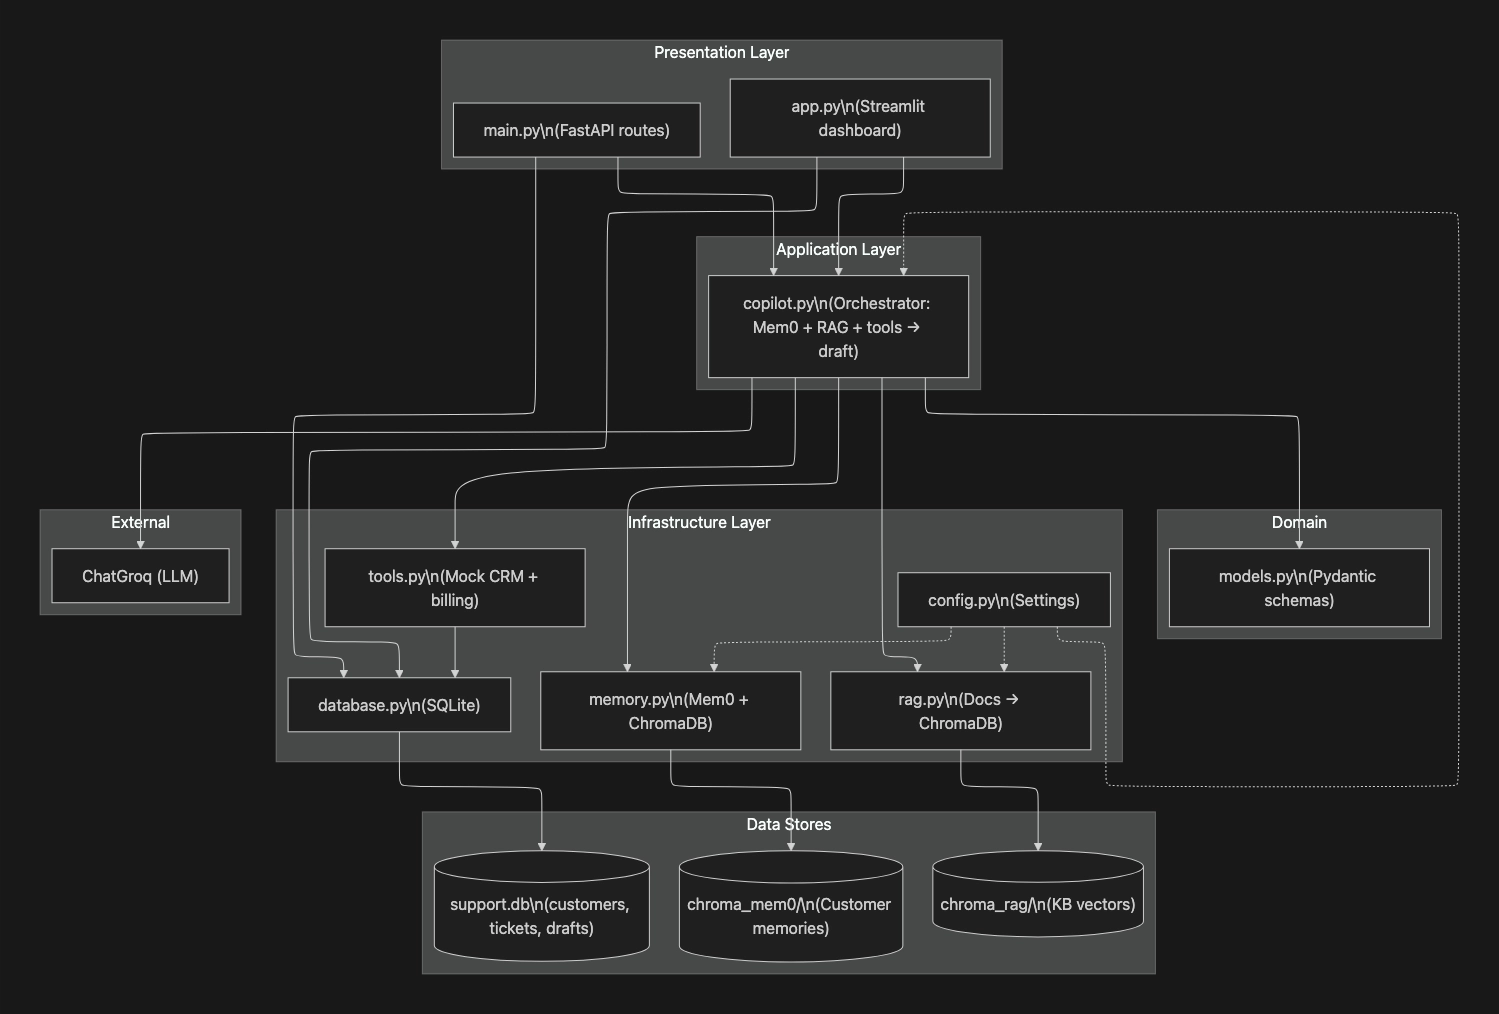

In [50]:
from IPython.display import Image, display

image_path = "/content/architecturediagram.png"

display(Image(filename=image_path))

---
## Phase 0 — Environment Setup & API Keys

In [1]:
import importlib.metadata

# Phase 0-A: Install all required packages (latest available releases)

!pip install -q -U \
    langchain \
    langchain-core \
    langchain-groq \
    langchain-community \
    langchain-text-splitters \
    langgraph \
    langgraph-checkpoint \
    faiss-cpu \
    sentence-transformers \
    pydantic \
    pydantic-settings \
    groq \
    tavily-python \


import langchain
import langchain_core
import langchain_groq
import langgraph

# Get langgraph version using importlib.metadata
try:
    langgraph_version = importlib.metadata.version('langgraph')
except importlib.metadata.PackageNotFoundError:
    langgraph_version = "N/A"

print("Installed versions:")
print(f"  langchain          {langchain.__version__}")
print(f"  langchain-core     {langchain_core.__version__}")
print(f"  langchain-groq     {langchain_groq.__version__}")
print(f"  langgraph          {langgraph_version}")

Installed versions:
  langchain          1.3.4
  langchain-core     1.4.0
  langchain-groq     1.1.2
  langgraph          1.2.4


In [2]:
!pip install -q numpy

In [3]:
# Phase 0-B: Load API keys from Colab Secrets  (Tools -> Secrets)
import os
from google.colab import userdata

def load_secret(name, required=True):
    try:
        val = userdata.get(name)
        if val:
            os.environ[name] = val
            print(f'  OK  {name}')
            return val
        print(f'  EMPTY  {name}')
        return ''
    except Exception as e:
        if required:
            raise RuntimeError(f'Required secret missing: {name}. Add it in Colab -> Tools -> Secrets') from e
        print(f'  MISSING (optional)  {name}')
        return ''

print('Loading secrets...')
GROQ_API_KEY   = load_secret('GROQ_API_KEY',  required=True)
TAVILY_API_KEY = load_secret('TAVILY_API_KEY', required=False)
print('Done.')


Loading secrets...
  OK  GROQ_API_KEY
  OK  TAVILY_API_KEY
Done.


---
## Phase 1 — Folder Structure

In [31]:
# Phase 1: Create package skeleton mirroring original project layout
import sys
from pathlib import Path

BASE = Path('/content/customer_support_agent')
for d in [
    BASE/'src'/'core',
    BASE/'src'/'integrations'/'memory',
    BASE/'src'/'integrations'/'rag',
    BASE/'src'/'integrations'/'tools',
    BASE/'src'/'repositories'/'sqlite',
    BASE/'src'/'services',
    BASE/'src'/'schemas',
    BASE/'knowledge_base', BASE/'data', BASE/'outputs',
]:
    d.mkdir(parents=True, exist_ok=True)

for d in [
    BASE/'src', BASE/'src'/'core',
    BASE/'src'/'integrations', BASE/'src'/'integrations'/'memory',
    BASE/'src'/'integrations'/'rag', BASE/'src'/'integrations'/'tools',
    BASE/'src'/'repositories', BASE/'src'/'repositories'/'sqlite',
    BASE/'src'/'services', BASE/'src'/'schemas',
]:
    p = d/'__init__.py'
    if not p.exists(): p.write_text('# package\n')

SRC = str(BASE/'src')
if SRC not in sys.path: sys.path.insert(0, SRC)
print('Structure created. sys.path includes:', SRC)


Structure created. sys.path includes: /content/customer_support_agent/src


---
## Phase 2 — Core Settings + SQLite Schema

In [32]:
# Phase 2-A: settings.py
from pathlib import Path

Path('/content/customer_support_agent/src/core/settings.py').write_text('''
from __future__ import annotations
from functools import lru_cache
from pathlib import Path
from pydantic_settings import BaseSettings, SettingsConfigDict

class Settings(BaseSettings):
    """All app config. Override via env vars or .env file."""
    model_config = SettingsConfigDict(env_file=".env", extra="ignore")
    app_name: str = "AI Support Copilot"
    # Groq -- two models; instant for agent loop, versatile for fallback
    groq_api_key:         str   = ""
    groq_model_instant:   str   = "llama-3.1-8b-instant"
    groq_model_versatile: str   = "llama-3.3-70b-versatile"
    llm_temperature:      float = 0.2
    max_tokens_per_call:  int   = 1024   # keep within Groq free-tier limits
    tavily_api_key: str = ""
    embedding_model: str = "all-MiniLM-L6-v2"  # local, no API key needed
    # Paths
    base_dir:           Path = Path("/content/customer_support_agent")
    data_dir:           Path = Path("/content/customer_support_agent/data")
    db_path:            Path = Path("/content/customer_support_agent/data/support.db")
    faiss_rag_dir:      Path = Path("/content/customer_support_agent/data/faiss_rag")
    faiss_mem_dir:      Path = Path("/content/customer_support_agent/data/faiss_mem")
    knowledge_base_dir: Path = Path("/content/customer_support_agent/knowledge_base")
    outputs_dir:        Path = Path("/content/customer_support_agent/outputs")
    # RAG / memory tuning
    rag_chunk_size: int = 800; rag_chunk_overlap: int = 120
    rag_top_k: int = 4;       mem_top_k: int = 5

@lru_cache
def get_settings() -> Settings: return Settings()

def ensure_directories(s=None):
    cfg = s or get_settings()
    for p in (cfg.data_dir, cfg.faiss_rag_dir, cfg.faiss_mem_dir,
              cfg.knowledge_base_dir, cfg.outputs_dir):
        Path(p).mkdir(parents=True, exist_ok=True)
''')
print('settings.py written')


settings.py written


In [33]:
# Phase 2-B: base.py (SQLite helpers + DDL)
from pathlib import Path

Path('/content/customer_support_agent/src/repositories/sqlite/base.py').write_text('''
from __future__ import annotations
import sqlite3, sys
from pathlib import Path
sys.path.insert(0, "/content/customer_support_agent/src")
from core.settings import ensure_directories, get_settings

def connect():
    s = get_settings(); ensure_directories(s)
    conn = sqlite3.connect(str(s.db_path), check_same_thread=False)
    conn.row_factory = sqlite3.Row
    conn.execute("PRAGMA foreign_keys = ON")
    return conn

def row_to_dict(row): return dict(row) if row is not None else None

def init_db():
    """Create all tables + trigger. Safe to call multiple times."""
    with connect() as c:
        c.executescript("""
            CREATE TABLE IF NOT EXISTS customers (
                id INTEGER PRIMARY KEY AUTOINCREMENT, email TEXT UNIQUE NOT NULL,
                name TEXT, company TEXT, created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP);
            CREATE TABLE IF NOT EXISTS tickets (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                customer_id INTEGER REFERENCES customers(id),
                subject TEXT NOT NULL, description TEXT NOT NULL,
                status TEXT DEFAULT \'open\', priority TEXT DEFAULT \'medium\',
                created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
                updated_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP);
            CREATE TABLE IF NOT EXISTS drafts (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                ticket_id INTEGER REFERENCES tickets(id),
                content TEXT NOT NULL, context_used TEXT,
                status TEXT DEFAULT \'pending\',
                created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP);
            CREATE TRIGGER IF NOT EXISTS tickets_updated_at
            AFTER UPDATE ON tickets FOR EACH ROW BEGIN
                UPDATE tickets SET updated_at=CURRENT_TIMESTAMP WHERE id=OLD.id;
            END;
        """)
''')
print('base.py written')


base.py written


In [34]:
# Phase 2-C: Initialise settings + DB
import sys, sqlite3
SRC='/content/customer_support_agent/src'
if SRC not in sys.path: sys.path.insert(0,SRC)
for m in list(sys.modules):
    if m.startswith(('core.','repositories.','integrations.','services.')):
        del sys.modules[m]
from core.settings import get_settings, ensure_directories
from repositories.sqlite.base import init_db
ensure_directories(); init_db()
s=get_settings()
print(f'instant model  : {s.groq_model_instant}')
print(f'versatile model: {s.groq_model_versatile}')
print(f'max_tokens     : {s.max_tokens_per_call}')
conn=sqlite3.connect(str(s.db_path))
tables=[r[0] for r in conn.execute("SELECT name FROM sqlite_master WHERE type='table'")]
conn.close(); print(f'SQLite tables: {tables}')


instant model  : llama-3.1-8b-instant
versatile model: llama-3.3-70b-versatile
max_tokens     : 1024
SQLite tables: ['customers', 'sqlite_sequence', 'tickets', 'drafts']


---
## Phase 3 — Knowledge Base Files

In [35]:
# Phase 3: Write banking FAQ markdown files
from pathlib import Path
KB=Path('/content/customer_support_agent/knowledge_base')

(KB/'banking-atm-cash-withdrawal-faq.md').write_text(
    '# ATM Cash Withdrawal FAQ\n\n'
    '## Daily Withdrawal Limits\n'
    '- Standard savings account: up to INR 25,000 per day.\n'
    '- Premium savings account: up to INR 50,000 per day.\n\n'
    '## Cash Debited But Not Dispensed\n'
    '- Reversal processed within 24 hours.\n'
    '- Raise dispute with: date/time, ATM ID, last 4 digits of card.\n\n'
    '## Card Blocked After Wrong PIN\n'
    '- Blocked after 3 wrong attempts. Auto-unblocked after 24h.\n'
    '- Bank staff NEVER ask for your PIN or OTP.\n'
)

(KB/'banking-charges-and-minimum-balance.md').write_text(
    '# Banking Charges and Minimum Balance\n\n'
    '## Minimum Balance\n'
    '- Urban branch: INR 10,000 monthly average.\n'
    '- Semi-urban: INR 5,000. Rural: INR 2,500.\n\n'
    '## Non-Maintenance Fee\n'
    '- INR 350 + taxes if balance falls below threshold (posted month-end).\n\n'
    '## Other Charges\n'
    '- SMS alert: INR 150/year. Debit card: INR 250/year.\n'
    '- Closure within 14 days: INR 200 charge.\n'
)

(KB/'banking-kyc-and-account-update-rules.md').write_text(
    '# KYC and Account Update Rules\n\n'
    '## KYC Validity\n'
    '- PAN-linked: 10 years. Aadhaar-based: 5 years.\n'
    '- KYC expiry freezes debit transactions.\n\n'
    '## Contact Update\n'
    '- Address: requires OVD. Mobile: OTP on registered email.\n'
    '## Periodic KYC by Risk\n'
    '- Low-risk: 10y. Medium-risk: 8y. High-risk: 2y.\n'
)

(KB/'saving-account-rule.md').write_text(
    '# Saving Account Rules\n\n'
    '1. Cheque book activated only after 1 month of opening.\n'
    '2. DMAT service NOT available for savings account holders.\n'
    '3. Internet banking active by default; branch PIN for first login.\n'
)

print('Knowledge-base files written:')
for f in sorted(KB.iterdir()): print(f'  {f.name}  ({f.stat().st_size}B)')


Knowledge-base files written:
  banking-atm-cash-withdrawal-faq.md  (435B)
  banking-charges-and-minimum-balance.md  (353B)
  banking-kyc-and-account-update-rules.md  (287B)
  saving-account-rule.md  (206B)


---
## Phase 4 — RAG Module (FAISS)

Replaces ChromaDB from original project.

**LangChain 1.2+ import:**
```python
from langchain_text_splitters import RecursiveCharacterTextSplitter
```


In [36]:
# Phase 4-A: Write faiss_kb.py
from pathlib import Path

Path('/content/customer_support_agent/src/integrations/rag/faiss_kb.py').write_text('''
from __future__ import annotations
import hashlib, pickle
from pathlib import Path
import numpy as np, faiss
from sentence_transformers import SentenceTransformer

# LangChain 1.2+ text-splitter import path (separate package since LC 1.x)
from langchain_text_splitters import RecursiveCharacterTextSplitter

from core.settings import Settings

class KnowledgeBaseService:
    """FAISS-backed RAG service. Replaces chromadb from original project."""
    _IDX="faiss_rag.index"; _META="faiss_rag_meta.pkl"

    def __init__(self, settings: Settings):
        self._s=settings
        self._ip=Path(settings.faiss_rag_dir)/self._IDX
        self._mp=Path(settings.faiss_rag_dir)/self._META
        self._model=SentenceTransformer(settings.embedding_model)
        # LangChain 1.2+ splitter
        self._splitter=RecursiveCharacterTextSplitter(
            chunk_size=settings.rag_chunk_size,
            chunk_overlap=settings.rag_chunk_overlap)
        self._index=None; self._docs=[]; self._metas=[]
        self._load()

    def ingest_directory(self, directory: Path, clear_existing=False)->dict:
        """Chunk and embed all .md/.txt files; persist FAISS index to disk."""
        if clear_existing: self._index,self._docs,self._metas=None,[],[]
        srcs=sorted(list(directory.glob("*.md"))+list(directory.glob("*.txt")))
        chunks,metas=[],[]
        for fp in srcs:
            for i,ch in enumerate(self._splitter.split_text(fp.read_text(encoding="utf-8"))):
                chunks.append(ch)
                metas.append({"source":fp.name,"chunk_index":i,
                               "hash":hashlib.sha1(ch.encode()).hexdigest()[:8]})
        if not chunks: return {"files_indexed":0,"chunks_indexed":0,"total_in_index":0}
        emb=self._model.encode(chunks,show_progress_bar=False)
        if self._index is None: self._index=faiss.IndexFlatL2(emb.shape[1])
        self._index.add(emb.astype(np.float32))
        self._docs.extend(chunks); self._metas.extend(metas)
        self._save()
        return {"files_indexed":len(srcs),"chunks_indexed":len(chunks),
                "total_in_index":self._index.ntotal}

    def search(self, query: str, top_k=None)->list:
        """Semantic search over indexed KB. Returns [{content,source,distance}]."""
        if self._index is None or self._index.ntotal==0: return []
        k=min(top_k or self._s.rag_top_k,self._index.ntotal)
        dists,idxs=self._index.search(self._model.encode([query]).astype(np.float32),k)
        return [{"content":self._docs[i],"source":self._metas[i].get("source","?"),
                 "distance":float(d)} for d,i in zip(dists[0],idxs[0]) if i>=0]

    def _save(self):
        if self._index is None: return
        faiss.write_index(self._index,str(self._ip))
        pickle.dump({"documents":self._docs,"metadatas":self._metas},open(self._mp,"wb"))

    def _load(self):
        if self._ip.exists() and self._mp.exists():
            try:
                self._index=faiss.read_index(str(self._ip))
                p=pickle.load(open(self._mp,"rb"))
                self._docs=p.get("documents",[]); self._metas=p.get("metadatas",[])
            except: self._index,self._docs,self._metas=None,[],[]
''')
print('faiss_kb.py written')


faiss_kb.py written


In [37]:
# Phase 4-B: Ingest KB + verify search
import json; from pathlib import Path
from core.settings import get_settings
from integrations.rag.faiss_kb import KnowledgeBaseService

settings=get_settings()
rag=KnowledgeBaseService(settings=settings)
result=rag.ingest_directory(settings.knowledge_base_dir,clear_existing=True)
print(f'Files: {result["files_indexed"]}  Chunks: {result["chunks_indexed"]}  Total: {result["total_in_index"]}')
print('\nTest search → ATM cash not dispensed:')
for i,h in enumerate(rag.search('ATM cash not dispensed',top_k=3),1):
    print(f'  [{i}] {h["source"]}  dist={h["distance"]:.3f}')
    print(f'       {h["content"][:80].strip()}...')
(Path(settings.outputs_dir)/'phase4_rag.json').write_text(json.dumps(result,indent=2))
print('Phase 4 output saved.')


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Files: 4  Chunks: 4  Total: 4

Test search → ATM cash not dispensed:
  [1] banking-atm-cash-withdrawal-faq.md  dist=0.984
       # ATM Cash Withdrawal FAQ

## Daily Withdrawal Limits
- Standard savings account...
  [2] saving-account-rule.md  dist=1.344
       # Saving Account Rules

1. Cheque book activated only after 1 month of opening....
  [3] banking-charges-and-minimum-balance.md  dist=1.666
       # Banking Charges and Minimum Balance

## Minimum Balance
- Urban branch: INR 10...
Phase 4 output saved.


---
## Phase 5 — Memory Store (FAISS)

Replaces `mem0`+ChromaDB. One `IndexFlatL2` per customer email/company.

In [38]:
# Phase 5-A: Write faiss_memory.py
from pathlib import Path

Path('/content/customer_support_agent/src/integrations/memory/faiss_memory.py').write_text('''
from __future__ import annotations
import pickle, re
from pathlib import Path
import numpy as np, faiss
from sentence_transformers import SentenceTransformer
from core.settings import Settings

class CustomerMemoryStore:
    """Per-customer FAISS memory. Replaces mem0+ChromaDB."""
    def __init__(self, settings: Settings):
        self._base=Path(settings.faiss_mem_dir)
        self._base.mkdir(parents=True,exist_ok=True)
        self._model=SentenceTransformer(settings.embedding_model)

    def add_resolution(self,user_id,ticket_subject,ticket_description,accepted_draft,entity_links=None):
        """Store an accepted draft as searchable memory."""
        ent=(" | entities: "+", ".join(entity_links)) if entity_links else ""
        text=f"Ticket: {ticket_subject} | Issue: {ticket_description[:200]} | Resolution: {accepted_draft[:300]}{ent}"
        self._add(user_id,text,{"type":"resolution","subject":ticket_subject})

    def add_interaction(self,user_id,user_input,assistant_response,metadata=None):
        self._add(user_id,f"User: {user_input[:200]} | Asst: {assistant_response[:300]}",metadata or {})

    def search(self,query,user_id,limit=5)->list:
        """Semantic search; returns [{memory,score,metadata}]."""
        idx,docs,metas=self._load(user_id)
        if idx is None or idx.ntotal==0: return []
        k=min(limit,idx.ntotal)
        dists,idxs=idx.search(self._model.encode([query]).astype("float32"),k)
        return [{"memory":docs[i],"score":round(1/(1+float(d)),4),"metadata":metas[i]}
                for d,i in zip(dists[0],idxs[0]) if i>=0]

    def list_memories(self,user_id,limit=20)->list:
        _,docs,metas=self._load(user_id)
        return [{"memory":d,"score":None,"metadata":m}
                for d,m in list(zip(reversed(docs),reversed(metas)))[:limit]]

    def _safe(self,uid): return re.sub(r"[^\\w\\-]","_",uid)[:80]
    def _paths(self,uid):
        s=self._safe(uid)
        return self._base/f"{s}.faiss",self._base/f"{s}.pkl"
    def _load(self,uid):
        ip,mp=self._paths(uid)
        if not ip.exists() or not mp.exists(): return None,[],[]
        try:
            idx=faiss.read_index(str(ip))
            p=pickle.load(open(mp,"rb"))
            return idx,p.get("docs",[]),p.get("metas",[])
        except: return None,[],[]
    def _save(self,uid,idx,docs,metas):
        ip,mp=self._paths(uid)
        faiss.write_index(idx,str(ip))
        pickle.dump({"docs":docs,"metas":metas},open(mp,"wb"))
    def _add(self,uid,text,meta):
        idx,docs,metas=self._load(uid)
        emb=self._model.encode([text]).astype("float32")
        if idx is None: idx=faiss.IndexFlatL2(emb.shape[1])
        idx.add(emb); docs.append(text); metas.append(meta)
        self._save(uid,idx,docs,metas)
''')
print('faiss_memory.py written')


faiss_memory.py written


In [39]:
# Phase 5-B: Smoke-test memory store
import json; from pathlib import Path
from core.settings import get_settings
from integrations.memory.faiss_memory import CustomerMemoryStore

settings=get_settings()
store=CustomerMemoryStore(settings=settings)
store.add_resolution('demo@test.com','ATM cash not dispensed',
    'Cash debited, ATM gave nothing. INR 10,000.',
    'Reversal raised. Funds back within 24h.',['region:India'])
hits=store.search('ATM reversal refund',user_id='demo@test.com',limit=3)
print('Memory hits:',len(hits))
for h in hits: print(f'  score={h["score"]}  {h["memory"][:70]}...')
(Path(settings.outputs_dir)/'phase5_memory.json').write_text(
    json.dumps({'hits':len(hits)},indent=2))
print('Phase 5 output saved.')


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Memory hits: 2
  score=0.5277  Ticket: ATM cash not dispensed | Issue: Cash debited, ATM gave nothing...
  score=0.5277  Ticket: ATM cash not dispensed | Issue: Cash debited, ATM gave nothing...
Phase 5 output saved.


---
## Phase 6 — LangChain Tools

**LangChain 1.2+ imports:**
```python
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
```


In [40]:
# Phase 6-A: Write support_tools.py
from pathlib import Path

Path('/content/customer_support_agent/src/integrations/tools/support_tools.py').write_text('''
from __future__ import annotations
import hashlib, json, os, sqlite3, sys

# LangChain 1.2+ canonical import for @tool decorator
from langchain_core.tools import tool

sys.path.insert(0,"/content/customer_support_agent/src")
from core.settings import get_settings

def _bucket(email,size): return int(hashlib.sha256(email.strip().lower().encode()).hexdigest(),16)%size
def _j(d): return json.dumps(d)
def _band(n): return "light" if n<=1 else ("moderate" if n<=3 else "heavy")

@tool
def lookup_customer_plan(customer_email: str)->str:
    """Return subscription plan and SLA for a customer email.
    Args: customer_email: customer email string.
    Returns: JSON with tool, customer_email, summary, details, recommended_action."""
    plans=[{"plan_tier":"free","sla_hours":48,"priority_queue":False},
           {"plan_tier":"starter","sla_hours":24,"priority_queue":False},
           {"plan_tier":"pro","sla_hours":8,"priority_queue":True},
           {"plan_tier":"enterprise","sla_hours":1,"priority_queue":True}]
    p=plans[_bucket(customer_email,len(plans))]
    return _j({"tool":"lookup_customer_plan","customer_email":customer_email,
               "summary":f"{customer_email} on {p[\'plan_tier\']} plan, SLA {p[\'sla_hours\']}h.",
               "details":p,"recommended_action":"Priority." if p["priority_queue"] else "Standard."})

@tool
def lookup_open_ticket_load(customer_email: str)->str:
    """Return open ticket count for a customer from SQLite.
    Args: customer_email: customer email string.
    Returns: JSON with tool, customer_email, summary, details, recommended_action."""
    s=get_settings()
    conn=sqlite3.connect(str(s.db_path)); conn.row_factory=sqlite3.Row
    row=conn.execute("SELECT id FROM customers WHERE email=?",(customer_email.strip().lower(),)).fetchone()
    if not row:
        conn.close()
        return _j({"tool":"lookup_open_ticket_load","customer_email":customer_email,
                   "summary":f"No record for {customer_email}.",
                   "details":{"customer_found":False,"open_tickets":None,"load_band":"unknown"},
                   "recommended_action":"Verify email."})
    cnt=conn.execute("SELECT COUNT(*) AS c FROM tickets t JOIN customers cu ON cu.id=t.customer_id "
                     "WHERE cu.email=? AND t.status=\'open\'",(customer_email.strip().lower(),)).fetchone()["c"]
    conn.close(); n=int(cnt)
    return _j({"tool":"lookup_open_ticket_load","customer_email":customer_email,
               "summary":f"{customer_email} has {n} open ticket(s). Load: {_band(n)}.",
               "details":{"customer_found":True,"open_tickets":n,"load_band":_band(n)},
               "recommended_action":"Acknowledge multiple issues." if n>1 else "Isolated incident."})

def get_support_tools(include_web_search=True)->list:
    """Return all LangChain tools for the agent."""
    tools=[lookup_customer_plan,lookup_open_ticket_load]
    if include_web_search and os.getenv("TAVILY_API_KEY"):
        try:
            # LangChain 1.2+ community import for Tavily
            from langchain_community.tools.tavily_search import TavilySearchResults
            tools.append(TavilySearchResults(max_results=3))
            print("  Tavily web-search tool added.")
        except Exception as e: print(f"  Tavily skipped: {e}")
    return tools
''')
print('support_tools.py written')
print('LangChain 1.2+ imports used:')
print('  from langchain_core.tools import tool')
print('  from langchain_community.tools.tavily_search import TavilySearchResults')


support_tools.py written
LangChain 1.2+ imports used:
  from langchain_core.tools import tool
  from langchain_community.tools.tavily_search import TavilySearchResults


In [41]:
# Phase 6-B: Test tools
import json
from integrations.tools.support_tools import lookup_customer_plan,lookup_open_ticket_load,get_support_tools

r1=json.loads(lookup_customer_plan.invoke({'customer_email':'priya@acme.com'}))
print('lookup_customer_plan:', r1['summary'])
r2=json.loads(lookup_open_ticket_load.invoke({'customer_email':'priya@acme.com'}))
print('lookup_open_ticket_load:', r2['summary'])
tools=get_support_tools()
print(f'\nTools registered: {len(tools)}')
for t in tools: print(f'  {t.name}')


lookup_customer_plan: priya@acme.com on free plan, SLA 48h.
lookup_open_ticket_load: No record for priya@acme.com.
  Tavily web-search tool added.

Tools registered: 3
  lookup_customer_plan
  lookup_open_ticket_load
  tavily_search_results_json


---
## Phase 7 — SupportCopilot (LangGraph ReAct Agent)

**LangChain 1.2+ / LangGraph 0.2+ imports:**
```python
from langchain_core.messages   import AIMessage, HumanMessage, SystemMessage, ToolMessage, BaseMessage
from langchain_groq            import ChatGroq
from langgraph.prebuilt        import create_react_agent
from langgraph.checkpoint.memory import MemorySaver
```


In [42]:
# Phase 7-A: Write copilot_service.py
from pathlib import Path

Path('/content/customer_support_agent/src/services/copilot_service.py').write_text('''
from __future__ import annotations
import json, re
from typing import Any

# ── LangChain 1.2+ imports ─────────────────────────────────────────────────
from langchain_core.messages import (
    AIMessage, BaseMessage, HumanMessage, SystemMessage, ToolMessage
)
from langchain_groq import ChatGroq

# ── LangGraph 0.2+ imports ─────────────────────────────────────────────────
from langgraph.prebuilt          import create_react_agent
from langgraph.checkpoint.memory import MemorySaver

from core.settings import Settings
from integrations.memory.faiss_memory import CustomerMemoryStore
from integrations.rag.faiss_kb        import KnowledgeBaseService
from integrations.tools.support_tools import get_support_tools


class SupportCopilot:
    """LangGraph ReAct agent with FAISS memory + RAG."""

    def __init__(self, settings: Settings):
        if not settings.groq_api_key:
            raise RuntimeError("GROQ_API_KEY missing. Add in Colab -> Tools -> Secrets.")
        self._s=settings
        # Instant model for agent tool-calling loop (fast, cheap)
        self._llm_instant=ChatGroq(
            model=settings.groq_model_instant, groq_api_key=settings.groq_api_key,
            temperature=settings.llm_temperature, max_tokens=settings.max_tokens_per_call)
        # Versatile model for fallback synthesis (smarter)
        self._llm_versatile=ChatGroq(
            model=settings.groq_model_versatile, groq_api_key=settings.groq_api_key,
            temperature=settings.llm_temperature, max_tokens=settings.max_tokens_per_call)
        # LangGraph 0.2+ ReAct agent + MemorySaver checkpoint
        self._tools=get_support_tools(include_web_search=True)
        self._agent=create_react_agent(
            model=self._llm_instant,
            tools=self._tools,
            checkpointer=MemorySaver())
        self.rag=KnowledgeBaseService(settings=settings)
        self._mem_error=None
        try: self.memory=CustomerMemoryStore(settings=settings)
        except Exception as e: self._mem_error=str(e); self.memory=None

    # ── Public API ──────────────────────────────────────────────────────────

    def generate_draft(self,ticket:dict,customer:dict)->dict:
        """Generate draft reply. Returns {draft, context_used}."""
        query=f"{ticket[\'subject\']}\\n{ticket[\'description\']}"
        mem_hits=self._fetch_memories(query,customer["email"],customer.get("company"))
        kb_hits=self.rag.search(query=query,top_k=self._s.rag_top_k)
        sys_msg=SystemMessage(content=self._system_prompt(mem_hits,kb_hits))
        usr_msg=HumanMessage(content=self._user_prompt(ticket,customer))
        result=self._agent.invoke(
            {"messages":[sys_msg,usr_msg]},
            config={"configurable":{"thread_id":self._thread_id(ticket,customer)},
                    "recursion_limit":20})
        draft,tool_calls=self._parse(result)
        used_fb=False
        if not draft:
            draft=self._llm_fallback(ticket,customer,mem_hits,kb_hits,tool_calls)
            used_fb=True
        if not draft:
            draft=self._det_fallback(ticket,customer,tool_calls)
            used_fb=True
        ctx=self._build_ctx(ticket,customer,mem_hits,kb_hits,tool_calls)
        if self._mem_error: ctx.setdefault("errors",[]).append(f"Memory disabled: {self._mem_error}")
        if used_fb: ctx.setdefault("errors",[]).append("Fallback synthesis used.")
        ctx["agent_runtime"]="langgraph_create_react_agent_v0.2"
        return {"draft":draft,"context_used":ctx}

    def save_accepted_resolution(self,customer_email,customer_company,ticket_subject,
                                  ticket_description,draft_content,context_used=None):
        """Persist accepted draft to FAISS memory for future context."""
        if self.memory is None: return
        ents=self._ent_links(ticket_subject,ticket_description,draft_content,context_used or {})
        for uid in self._scope_ids(customer_email,customer_company):
            self.memory.add_resolution(uid,ticket_subject,ticket_description,draft_content,ents)

    def search_customer_memories(self,customer_email,query,customer_company=None,limit=10):
        return self._fetch_memories(query,customer_email,customer_company,limit)

    # ── Private helpers ──────────────────────────────────────────────────────

    def _fetch_memories(self,query,email,company,limit=None):
        if self.memory is None: return []
        lim=limit or self._s.mem_top_k; hits=[]
        for uid in self._scope_ids(email,company):
            hits.extend(self.memory.search(query=query,user_id=uid,limit=lim))
        return self._dedupe(hits,lim)

    @staticmethod
    def _scope_ids(email,company):
        ids=[email.strip().lower()]
        if company:
            n=re.sub(r"[^a-z0-9]+","-",company.strip().lower()).strip("-")
            if n: ids.append(f"company::{n}")
        return ids

    @staticmethod
    def _dedupe(hits,limit):
        seen,out=set(),[]
        for h in hits:
            k=str(h.get("memory","")).strip().lower()
            if not k or k in seen: continue
            seen.add(k); out.append(h)
            if len(out)>=limit: break
        return out

    def _system_prompt(self,mem_hits,kb_hits)->str:
        """Build system prompt with memory + KB context injection."""
        mem_block=("\\n".join(f"- {h[\'memory\'][:160]}" for h in mem_hits)
                   if mem_hits else "- No prior memories found.")
        kb_block=("\\n".join(f"- [{h[\'source\']}] {h[\'content\'][:180]}" for h in kb_hits)
                  if kb_hits else "- No KB chunks found.")
        return (
            "You are an AI copilot for customer support agents. "
            "Write concise, empathetic, actionable draft replies.\\n"
            "Call tools when ticket implies billing, plan, or account checks.\\n\\n"
            f"=== Customer Memory ===\\n{mem_block}\\n\\n"
            f"=== Knowledge Base ===\\n{kb_block}\\n\\n"
            "Rules:\\n"
            "1. Open with empathy and direct acknowledgement.\\n"
            "2. Provide clear next steps.\\n"
            "3. Reference KB/tool data; never expose internal reasoning.\\n"
            "4. Keep reply under 150 words."
        )

    @staticmethod
    def _user_prompt(ticket,customer)->str:
        return (f"Customer: {customer.get(\'name\') or \'Unknown\'} ({customer[\'email\']})"
                f"\\nCompany: {customer.get(\'company\') or \'Unknown\'}"
                f"\\nSubject: {ticket[\'subject\']}  Priority: {ticket.get(\'priority\',\'medium\')}"
                f"\\nDescription:\\n{ticket[\'description\'][:500]}"
                "\\n\\nWrite draft. Call tools if billing/plan check needed.")

    @staticmethod
    def _thread_id(ticket,customer):
        tid=ticket.get("id")
        return f"ticket::{tid}" if tid else f"ticket::{customer.get(\'email\',\'?\')}"

    def _parse(self,result):
        """Extract final draft text + tool call trace from LangGraph result."""
        raw=(result.get("messages",[]) if isinstance(result,dict)
             else getattr(result,"messages",[]))
        msgs=[m for m in raw if isinstance(m,BaseMessage)]
        draft=""
        for m in reversed(msgs):
            if isinstance(m,AIMessage):
                c=self._cstr(m).strip()
                if c: draft=c; break
        tm_by_id={m.tool_call_id:m for m in msgs
                  if isinstance(m,ToolMessage) and m.tool_call_id}
        tool_calls=[]
        for m in msgs:
            if not isinstance(m,AIMessage): continue
            for call in (getattr(m,"tool_calls",None) or []):
                name=call.get("name","?"); cid=call.get("id")
                tr={"tool_name":name,"tool_call_id":cid,"arguments":call.get("args",{})}
                tm=tm_by_id.get(str(cid)) if cid else None
                if tm is None:
                    tr.update({"status":"skipped","summary":f"{name} had no result.",
                               "output":None,"output_text":""})
                else:
                    raw_out=self._cstr(tm)
                    parsed=self._parse_json(raw_out)
                    tr.update({"status":"error" if getattr(tm,"status",None)=="error" else "ok",
                               "summary":(parsed or {}).get("summary") or raw_out[:120],
                               "output":parsed,"output_text":raw_out})
                tool_calls.append(tr)
        return draft,tool_calls

    @staticmethod
    def _cstr(m):
        c=getattr(m,"content",m)
        return "\\n".join(str(x) for x in c) if isinstance(c,list) else str(c)

    @staticmethod
    def _parse_json(raw):
        try:
            p=json.loads(raw)
            return p if isinstance(p,dict) else None
        except: return None

    def _llm_fallback(self,ticket,customer,mem_hits,kb_hits,tool_calls)->str:
        """Fallback: ask versatile model directly without tool loop."""
        prompt=(f"Customer: {customer.get(\'name\')} ({customer.get(\'email\')})"
                f"\\nSubject: {ticket.get(\'subject\')}\\nDesc: {ticket.get(\'description\',\'\')[:400]}"
                f"\\nMemory: {[h[\'memory\'][:120] for h in mem_hits[:2]] or [\'none\']}"
                f"\\nKB: {[h[\'content\'][:120] for h in kb_hits[:2]] or [\'none\']}"
                f"\\nTools: {[str(t.get(\'summary\',\'\'))[:120] for t in tool_calls] or [\'none\']}"
                "\\n\\nWrite concise empathetic draft reply under 150 words.")
        try:
            resp=self._llm_versatile.invoke([
                SystemMessage(content="You are an AI support copilot. Produce ONLY the final reply."),
                HumanMessage(content=prompt)])
            return self._cstr(resp).strip()
        except: return ""

    @staticmethod
    def _det_fallback(ticket,customer,tool_calls)->str:
        """Last-resort deterministic template — guaranteed non-empty."""
        name=customer.get("name") or customer.get("email") or "there"
        best=next((str(t.get("summary","")).strip() for t in tool_calls if t.get("summary")),
                  "Our support team is reviewing your issue.")
        return (f"Hi {name},\\n\\nThank you for contacting us about \'" +
                ticket.get("subject","your issue") +
                f"\'.\'\\n\\n{best}\\n\\nBest regards,\\nSupport Team")

    def _build_ctx(self,ticket,customer,mem_hits,kb_hits,tool_calls)->dict:
        """Build structured context_used dict (v2 schema) for auditability."""
        return {
            "version":2,
            "ticket":{"id":ticket.get("id"),"subject":ticket.get("subject"),
                      "priority":ticket.get("priority"),"status":ticket.get("status")},
            "customer":{"id":customer.get("id"),"email":customer.get("email"),
                        "name":customer.get("name"),"company":customer.get("company")},
            "signals":{"memory_hit_count":len(mem_hits),"knowledge_hit_count":len(kb_hits),
                       "tool_call_count":len(tool_calls),
                       "knowledge_sources":list({h.get("source") for h in kb_hits})},
            "highlights":{"memory":[str(h.get("memory",""))[:160] for h in mem_hits[:3]],
                           "knowledge":[f"[{h.get(\'source\')}] {h.get(\'content\',\'\')[:160]}" for h in kb_hits[:3]],
                           "tools":[str(t.get("summary",""))[:160] for t in tool_calls[:3]]},
            "memory_hits":mem_hits,"knowledge_hits":kb_hits,"tool_calls":tool_calls}

    def _ent_links(self,subject,description,draft,context)->list:
        """Extract entity tags for memory annotation."""
        merged=f"{subject}\\n{description}\\n{draft}".lower()
        links=[]
        for code in re.findall(r"\\b([45]\\d\\d)\\b",merged)[:4]: links.append(f"http:{code}")
        for region,markers in [("India",["india"," in "]),("EU",["europe"]),("US",["united states"])]:
            if any(m in merged for m in markers): links.append(f"region:{region}")
        for tc in context.get("tool_calls",[]):
            d=(tc.get("output") or {}).get("details") or {}
            if isinstance(d,dict) and d.get("plan_tier"): links.append(f"plan:{d[\'plan_tier\']}")
        return list(dict.fromkeys(links))[:12]
''')
print('copilot_service.py written')
print('LangChain 1.2+ / LangGraph 0.2+ imports used:')
print('  from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage, BaseMessage')
print('  from langchain_groq import ChatGroq')
print('  from langgraph.prebuilt import create_react_agent')
print('  from langgraph.checkpoint.memory import MemorySaver')


copilot_service.py written
LangChain 1.2+ / LangGraph 0.2+ imports used:
  from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage, BaseMessage
  from langchain_groq import ChatGroq
  from langgraph.prebuilt import create_react_agent
  from langgraph.checkpoint.memory import MemorySaver


In [43]:
# Phase 7-B: Instantiate SupportCopilot
from core.settings import get_settings
from services.copilot_service import SupportCopilot

settings=get_settings()
copilot=SupportCopilot(settings=settings)
print('SupportCopilot ready')
print(f'  instant model   : {settings.groq_model_instant}')
print(f'  versatile model : {settings.groq_model_versatile}')
print(f'  tools           : {[t.name for t in copilot._tools]}')
print(f'  memory          : {"active" if copilot.memory else "disabled: "+str(copilot._mem_error)}')


  Tavily web-search tool added.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


SupportCopilot ready
  instant model   : llama-3.1-8b-instant
  versatile model : llama-3.3-70b-versatile
  tools           : ['lookup_customer_plan', 'lookup_open_ticket_load', 'tavily_search_results_json']
  memory          : active


---
## Phase 8 — Repository Layer

In [44]:
# Phase 8: Write all repository files
from pathlib import Path
BASE=Path('/content/customer_support_agent/src/repositories/sqlite')

# customers.py
(BASE/'customers.py').write_text('''
from __future__ import annotations
from repositories.sqlite.base import connect, row_to_dict

class CustomersRepository:
    def create_or_get(self,email,name=None,company=None):
        """Upsert customer by email; backfill name/company if blank."""
        with connect() as c:
            row=c.execute("SELECT * FROM customers WHERE email=?",(email,)).fetchone()
            if row:
                ups,vals=[],[]
                if name and not row["name"]: ups.append("name=?"); vals.append(name)
                if company and not row["company"]: ups.append("company=?"); vals.append(company)
                if ups:
                    vals.append(email)
                    c.execute(f"UPDATE customers SET {', '.join(ups)} WHERE email=?",vals)
                return row_to_dict(c.execute("SELECT * FROM customers WHERE email=?",(email,)).fetchone())
            c.execute("INSERT INTO customers (email,name,company) VALUES(?,?,?)",(email,name,company))
            return row_to_dict(c.execute("SELECT * FROM customers WHERE email=?",(email,)).fetchone())
    def get_by_id(self,cid):
        with connect() as c: return row_to_dict(c.execute("SELECT * FROM customers WHERE id=?",(cid,)).fetchone())
    def get_by_email(self,email):
        with connect() as c: return row_to_dict(c.execute("SELECT * FROM customers WHERE email=?",(email,)).fetchone())
''')

# tickets.py
(BASE/'tickets.py').write_text('''
from __future__ import annotations
from repositories.sqlite.base import connect, row_to_dict

class TicketsRepository:
    def create(self,customer_id,subject,description,priority="medium",status="open"):
        with connect() as c:
            cur=c.execute("INSERT INTO tickets (customer_id,subject,description,priority,status) VALUES(?,?,?,?,?)",
                          (customer_id,subject,description,priority,status))
            return row_to_dict(c.execute("SELECT * FROM tickets WHERE id=?",(cur.lastrowid,)).fetchone())
    def list(self,limit=100):
        with connect() as c:
            rows=c.execute("SELECT t.*,cu.email AS customer_email,cu.name AS customer_name,cu.company AS customer_company "
                           "FROM tickets t JOIN customers cu ON cu.id=t.customer_id ORDER BY t.created_at DESC LIMIT ?",(limit,)).fetchall()
            return [dict(r) for r in rows]
    def get_by_id(self,tid):
        with connect() as c:
            row=c.execute("SELECT t.*,cu.email AS customer_email,cu.name AS customer_name,cu.company AS customer_company "
                          "FROM tickets t JOIN customers cu ON cu.id=t.customer_id WHERE t.id=?",(tid,)).fetchone()
            return row_to_dict(row)
    def set_status(self,tid,status):
        with connect() as c:
            c.execute("UPDATE tickets SET status=? WHERE id=?",(status,tid))
            return row_to_dict(c.execute("SELECT * FROM tickets WHERE id=?",(tid,)).fetchone())
    def count_open_for_customer(self,email):
        with connect() as c:
            row=c.execute("SELECT COUNT(*) AS n FROM tickets t JOIN customers cu ON cu.id=t.customer_id "
                          "WHERE cu.email=? AND t.status=\'open\'",(email,)).fetchone()
            return int(row["n"]) if row else 0
''')

# drafts.py
(BASE/'drafts.py').write_text('''
from __future__ import annotations
from repositories.sqlite.base import connect, row_to_dict

class DraftsRepository:
    def create(self,ticket_id,content,context_used=None,status="pending"):
        with connect() as c:
            cur=c.execute("INSERT INTO drafts (ticket_id,content,context_used,status) VALUES(?,?,?,?)",
                          (ticket_id,content,context_used,status))
            return row_to_dict(c.execute("SELECT * FROM drafts WHERE id=?",(cur.lastrowid,)).fetchone())
    def get_latest_for_ticket(self,tid):
        with connect() as c:
            return row_to_dict(c.execute("SELECT * FROM drafts WHERE ticket_id=? ORDER BY created_at DESC LIMIT 1",(tid,)).fetchone())
    def get_by_id(self,did):
        with connect() as c: return row_to_dict(c.execute("SELECT * FROM drafts WHERE id=?",(did,)).fetchone())
    def update(self,did,content=None,status=None):
        ups,vals=[],[]
        if content is not None: ups.append("content=?"); vals.append(content)
        if status  is not None: ups.append("status=?");  vals.append(status)
        if not ups: return self.get_by_id(did)
        with connect() as c:
            vals.append(did)
            c.execute(f"UPDATE drafts SET {', '.join(ups)} WHERE id=?",vals)
            return row_to_dict(c.execute("SELECT * FROM drafts WHERE id=?",(did,)).fetchone())
    def get_ticket_and_customer_by_draft(self,did):
        with connect() as c:
            row=c.execute("SELECT d.id AS draft_id,d.ticket_id,d.content AS draft_content,d.status AS draft_status,"
                          "t.subject,t.description,t.status AS ticket_status,"
                          "cu.id AS customer_id,cu.email AS customer_email,cu.name AS customer_name,cu.company AS customer_company "
                          "FROM drafts d JOIN tickets t ON t.id=d.ticket_id JOIN customers cu ON cu.id=t.customer_id "
                          "WHERE d.id=?",(did,)).fetchone()
            return row_to_dict(row)
''')

# __init__.py convenience layer
(BASE/'__init__.py').write_text('''
from repositories.sqlite.base      import init_db
from repositories.sqlite.customers import CustomersRepository
from repositories.sqlite.tickets   import TicketsRepository
from repositories.sqlite.drafts    import DraftsRepository
_c=CustomersRepository(); _t=TicketsRepository(); _d=DraftsRepository()
def create_or_get_customer(e,n=None,co=None): return _c.create_or_get(e,n,co)
def get_customer_by_id(i):    return _c.get_by_id(i)
def create_ticket(ci,s,d,p="medium",st="open"): return _t.create(ci,s,d,p,st)
def list_tickets(l=100):      return _t.list(l)
def get_ticket_by_id(i):      return _t.get_by_id(i)
def set_ticket_status(i,s):   return _t.set_status(i,s)
def create_draft(ti,c,ctx=None,s="pending"): return _d.create(ti,c,ctx,s)
def get_latest_draft(ti):     return _d.get_latest_for_ticket(ti)
def update_draft(di,c=None,s=None): return _d.update(di,c,s)
def get_ticket_and_customer_by_draft(di): return _d.get_ticket_and_customer_by_draft(di)
''')
print('Repository files written: customers.py, tickets.py, drafts.py, __init__.py')


Repository files written: customers.py, tickets.py, drafts.py, __init__.py


---
## Phase 9 — Service Layer

In [45]:
# Phase 9: Write draft_service.py and knowledge_service.py
from pathlib import Path
SVC=Path('/content/customer_support_agent/src/services')

(SVC/'draft_service.py').write_text('''
from __future__ import annotations
import json, logging
from repositories.sqlite.customers import CustomersRepository
from repositories.sqlite.drafts    import DraftsRepository
from repositories.sqlite.tickets   import TicketsRepository
from services.copilot_service      import SupportCopilot
logger=logging.getLogger(__name__)

class DraftService:
    def generate_and_store(self,ticket_id,tickets_repo,customers_repo,drafts_repo,copilot):
        """Fetch ticket+customer, call AI copilot, persist draft to DB."""
        ticket=tickets_repo.get_by_id(ticket_id)
        customer=customers_repo.get_by_id(ticket["customer_id"]) if ticket else None
        if not ticket or not customer: return None
        try:
            res=copilot.generate_draft(ticket=ticket,customer=customer)
            text,ctx=self._norm(res)
            return drafts_repo.create(ticket_id=ticket_id,content=text,
                                      context_used=json.dumps(ctx),status="pending")
        except Exception as e:
            logger.exception("Draft failed ticket_id=%s",ticket_id)
            return drafts_repo.create(ticket_id=ticket_id,
                content="Draft generation failed. Please retry.",
                context_used=json.dumps({"errors":[str(e)]}),status="failed")

    def accept_draft(self,draft_id,drafts_repo,copilot,new_content=None):
        """Accept draft: update status, save resolution to memory."""
        info=drafts_repo.get_ticket_and_customer_by_draft(draft_id)
        if not info: return None
        content=new_content or info["draft_content"]
        updated=drafts_repo.update(draft_id,content=content,status="accepted")
        if updated:
            ctx=json.loads(updated.get("context_used") or "{}")
            try:
                copilot.save_accepted_resolution(
                    customer_email=info["customer_email"],
                    customer_company=info.get("customer_company"),
                    ticket_subject=info["subject"],
                    ticket_description=info["description"],
                    draft_content=content,context_used=ctx)
            except Exception as e: logger.warning("Memory save failed: %s",e)
        return updated

    def discard_draft(self,draft_id,drafts_repo):
        return drafts_repo.update(draft_id,status="discarded")

    def serialize_draft(self,draft):
        raw=draft.get("context_used")
        ctx=None
        if raw:
            try: ctx=json.loads(raw)
            except: ctx={"raw":raw}
        return {"id":draft["id"],"ticket_id":draft["ticket_id"],
                "content":draft["content"],"context_used":ctx,
                "status":draft["status"],"created_at":draft["created_at"]}

    @staticmethod
    def _norm(result):
        text=str(result.get("draft") or "").strip()
        ctx=result.get("context_used") or {}
        if not isinstance(ctx,dict): ctx={"raw":str(ctx)}
        if not text:
            text="Thank you for reaching out. We are reviewing your issue."
            ctx.setdefault("errors",[]).append("Empty draft; fallback text used.")
        return text,ctx
''')

(SVC/'knowledge_service.py').write_text('''
from core.settings import Settings
from integrations.rag.faiss_kb import KnowledgeBaseService

class KnowledgeService:
    def __init__(self,settings:Settings): self._s=settings
    def ingest(self,clear_existing=False)->dict:
        """Ingest all KB files from knowledge_base_dir."""
        return KnowledgeBaseService(settings=self._s).ingest_directory(
            self._s.knowledge_base_dir,clear_existing=clear_existing)
''')
print('draft_service.py + knowledge_service.py written')


draft_service.py + knowledge_service.py written


---
## Phase 10 — End-to-End Demo

In [46]:
# Phase 10: Create customer + ticket -> generate AI draft
import json; from pathlib import Path
from repositories.sqlite.base      import init_db
from repositories.sqlite.customers import CustomersRepository
from repositories.sqlite.tickets   import TicketsRepository
from repositories.sqlite.drafts    import DraftsRepository
from services.draft_service        import DraftService
from core.settings                 import get_settings

init_db()
settings=get_settings()
cr=CustomersRepository(); tr=TicketsRepository(); dr=DraftsRepository(); svc=DraftService()

customer=cr.create_or_get(email='priya.sharma@acme-banking.com',
    name='Priya Sharma',company='Acme Banking Ltd')
print(f'Customer: #{customer["id"]} {customer["name"]} ({customer["email"]})')

ticket=tr.create(customer_id=customer['id'],
    subject='ATM cash not dispensed - urgent refund needed',
    description=('I withdrew INR 10,000 from ATM at MG Road branch 26 May 2026. '
                 'Cash was debited but ATM did not dispense. '
                 'ATM ID: MG-ROAD-001, Time: 14:35 IST. Need urgent reversal.'),
    priority='high')
print(f'Ticket  : #{ticket["id"]} {ticket["subject"]}')

print('\nGenerating AI draft via Groq + LangGraph ReAct agent...')
draft_row=svc.generate_and_store(ticket_id=ticket['id'],
    tickets_repo=tr,customers_repo=cr,drafts_repo=dr,copilot=copilot)
s=svc.serialize_draft(draft_row)
print('='*60)
print('GENERATED DRAFT:')
print('='*60)
print(s['content'])
print('='*60)
ctx=s.get('context_used') or {}; sig=ctx.get('signals') or {}
print(f'Status : {s["status"]} | Memory: {sig.get("memory_hit_count",0)} | KB: {sig.get("knowledge_hit_count",0)} | Tools: {sig.get("tool_call_count",0)}')
if ctx.get('tool_calls'):
    for tc in ctx['tool_calls']: print(f'  Tool: {tc["tool_name"]} -> {str(tc.get("summary",""))[:80]}')
(Path(settings.outputs_dir)/'phase10_demo.json').write_text(json.dumps(
    {'ticket_id':ticket['id'],'draft_status':s['status'],'signals':sig,
     'draft_preview':s['content'][:200]},indent=2,ensure_ascii=False))
print('Phase 10 output saved.')
DEMO_CUSTOMER=customer; DEMO_TICKET=ticket; DEMO_DRAFT_ROW=draft_row


Customer: #1 Priya Sharma (priya.sharma@acme-banking.com)
Ticket  : #3 ATM cash not dispensed - urgent refund needed

Generating AI draft via Groq + LangGraph ReAct agent...
GENERATED DRAFT:
Dear Priya,

Thank you for reaching out to us about the issue with your ATM cash withdrawal. I'm here to help you with this urgent matter.

According to our records, you withdrew INR 10,000 from the ATM at MG Road branch on 26 May 2026. I've checked your account details, and I see that the cash was debited from your account, but unfortunately, the ATM did not dispense the cash.

I've escalated this issue to our team, and we will process an urgent refund for you. You can expect the refund to be credited back to your account within the next 48 hours, as per our standard SLA for free plan customers.

Please note that you will not be charged for this transaction, and we apologize again for the inconvenience caused.

If you have any further questions or concerns, please don't hesitate to reach out to me

---
## Phase 11 — Memory Probe

In [47]:
# Phase 11: Accept draft -> save memory -> probe
import json; from pathlib import Path
from repositories.sqlite.drafts import DraftsRepository
from core.settings import get_settings

settings=get_settings(); dr=DraftsRepository()
accepted=svc.accept_draft(DEMO_DRAFT_ROW['id'],drafts_repo=dr,
    copilot=copilot,new_content=DEMO_DRAFT_ROW['content'])
print(f'Draft #{accepted["id"]} status -> {accepted["status"]}')

print('\nSearching memory: ATM cash reversal refund')
mems=copilot.search_customer_memories(
    customer_email=DEMO_CUSTOMER['email'],query='ATM cash reversal refund',
    customer_company=DEMO_CUSTOMER.get('company'),limit=5)
if mems:
    print(f'Memory hits: {len(mems)}')
    for m in mems: print(f'  score={m["score"]}  {m["memory"][:80]}...')
else: print('No hits yet (need prior accepted drafts)')

ctx=json.loads(DEMO_DRAFT_ROW.get('context_used') or '{}')
print('\nSignals:', json.dumps(ctx.get('signals',{}),indent=2))
(Path(settings.outputs_dir)/'phase11_memory.json').write_text(json.dumps(
    {'memories_found':len(mems),'signals':ctx.get('signals',{})},indent=2))
print('Phase 11 output saved.')

Draft #3 status -> accepted

Searching memory: ATM cash reversal refund
Memory hits: 1
  score=0.5636  Ticket: ATM cash not dispensed - urgent refund needed | Issue: I withdrew INR 10...

Signals: {
  "memory_hit_count": 0,
  "knowledge_hit_count": 4,
  "tool_call_count": 1,
  "knowledge_sources": [
    "banking-atm-cash-withdrawal-faq.md",
    "saving-account-rule.md",
    "banking-charges-and-minimum-balance.md",
    "banking-kyc-and-account-update-rules.md"
  ]
}
Phase 11 output saved.


---
## Phase 12 — Deployment Guide

In [48]:
# Phase 12: Write DEPLOYMENT.md
from pathlib import Path
deploy = '# Deployment Guide - AI Customer Support Agent (EC2, no Docker)\\n\\n## APIs Required\\n| Variable | Purpose | Required |\\n|---|---|---|\\n| GROQ_API_KEY | Groq LLM inference | YES |\\n| TAVILY_API_KEY | Web-search tool | Optional |\\n\\n---\\n\\n## Step 1 - Launch EC2\\n- Ubuntu 22.04 LTS, t3.small minimum (2 vCPU, 2GB RAM, 20GB gp3)\\n- Security group: port 22 (SSH, restrict to your IP), port 8000 (API)\\n\\n## Step 2 - SSH\\n```\\nssh -i key.pem ubuntu@<EC2_IP>\\n```\\n\\n## Step 3 - System packages\\n```\\nsudo apt-get update -y && sudo apt-get install -y python3.11 python3.11-venv python3-pip git\\n```\\n\\n## Step 4 - Upload project\\n```\\nscp -i key.pem -r ./customer_support_agent ubuntu@<EC2_IP>:/opt/\\n```\\n\\n## Step 5 - Virtual environment\\n```\\ncd /opt/customer_support_agent && python3.11 -m venv .venv && source .venv/bin/activate\\npip install "langchain>=1.2.0" "langchain-core>=0.3.0" "langchain-groq>=0.2.0" \\\n    "langchain-community>=0.3.0" "langchain-text-splitters>=0.3.0" \\\n    "langgraph>=0.2.0" "faiss-cpu>=1.8.0" "sentence-transformers>=3.0.0" \\\n    "pydantic>=2.7.0" "pydantic-settings>=2.3.0" "groq>=0.9.0"\\n```\\n\\n## Step 6 - Environment variables\\n```\\ncat > /opt/customer_support_agent/.env << EOF\\nGROQ_API_KEY=your_key_here\\nTAVILY_API_KEY=your_key_here\\nEOF\\nchmod 600 .env\\n```\\n\\n## Step 7 - Init DB and ingest KB\\n```\\nexport PYTHONPATH=/opt/customer_support_agent/src\\npython3 -c "from repositories.sqlite.base import init_db; init_db()"\\npython3 -c "from core.settings import get_settings; from services.knowledge_service import KnowledgeService; KnowledgeService(get_settings()).ingest(True)"\\n```\\n\\n## Step 8 - systemd service\\nCreate /etc/systemd/system/support-agent.service:\\n```\\n[Unit]\\nDescription=AI Support Agent\\nAfter=network.target\\n[Service]\\nUser=ubuntu\\nWorkingDirectory=/opt/customer_support_agent\\nEnvironmentFile=/opt/customer_support_agent/.env\\nEnvironment=PYTHONPATH=/opt/customer_support_agent/src\\nExecStart=/opt/customer_support_agent/.venv/bin/uvicorn main:app --host 0.0.0.0 --port 8000\\nRestart=on-failure\\n[Install]\\nWantedBy=multi-user.target\\n```\\n\\n```\\nsudo systemctl daemon-reload && sudo systemctl enable support-agent && sudo systemctl start support-agent\\n```\\n\\n## Step 9 - Verify\\n```\\ncurl http://localhost:8000/health\\n```\\n\\n## Step 10 - Logs\\n```\\nsudo journalctl -u support-agent -f\\n```\\n\\n## Security Checklist\\n- API keys in .env (chmod 600), never in source code\\n- Port 22 restricted to your IP\\n- HTTPS via Nginx + Certbot before public exposure\\n- Rotate GROQ_API_KEY regularly\\n'
Path('/content/customer_support_agent/DEPLOYMENT.md').write_text(deploy)
print('DEPLOYMENT.md written.')
print('\nPreview (first 20 lines):')
for line in deploy.splitlines()[:20]: print(' ', line)


DEPLOYMENT.md written.

Preview (first 20 lines):
  # Deployment Guide - AI Customer Support Agent (EC2, no Docker)\n\n## APIs Required\n| Variable | Purpose | Required |\n|---|---|---|\n| GROQ_API_KEY | Groq LLM inference | YES |\n| TAVILY_API_KEY | Web-search tool | Optional |\n\n---\n\n## Step 1 - Launch EC2\n- Ubuntu 22.04 LTS, t3.small minimum (2 vCPU, 2GB RAM, 20GB gp3)\n- Security group: port 22 (SSH, restrict to your IP), port 8000 (API)\n\n## Step 2 - SSH\n```\nssh -i key.pem ubuntu@<EC2_IP>\n```\n\n## Step 3 - System packages\n```\nsudo apt-get update -y && sudo apt-get install -y python3.11 python3.11-venv python3-pip git\n```\n\n## Step 4 - Upload project\n```\nscp -i key.pem -r ./customer_support_agent ubuntu@<EC2_IP>:/opt/\n```\n\n## Step 5 - Virtual environment\n```\ncd /opt/customer_support_agent && python3.11 -m venv .venv && source .venv/bin/activate\npip install "langchain>=1.2.0" "langchain-core>=0.3.0" "langchain-groq>=0.2.0" \
      "langchain-community>=0.3.0" "l

---
## Phase 13 — Zip All Outputs + Download

In [49]:
# Phase 13: Zip everything and download
import zipfile; from pathlib import Path; from datetime import datetime

PROJECT=Path('/content/customer_support_agent')
ARCHIVE=f'/content/customer_support_agent_{datetime.now().strftime("%Y%m%d_%H%M%S")}.zip'
SKIP={'__pycache__','.ipynb_checkpoints','faiss_rag','faiss_mem'}

with zipfile.ZipFile(ARCHIVE,'w',compression=zipfile.ZIP_DEFLATED) as zf:
    for item in sorted(PROJECT.rglob('*')):
        if any(p in SKIP for p in item.parts): continue
        if item.is_file():
            zf.write(item,'customer_support_agent/'+str(item.relative_to(PROJECT)))

print(f'Archive: {ARCHIVE}  ({Path(ARCHIVE).stat().st_size//1024} KB)')
print('Contents:')
with zipfile.ZipFile(ARCHIVE) as zf:
    for n in sorted(zf.namelist()): print(f'  {n}')
try:
    from google.colab import files
    files.download(ARCHIVE)
    print('Download started.')
except: print(f'Run: from google.colab import files; files.download("{ARCHIVE}")')


Archive: /content/customer_support_agent_20260604_042009.zip  (23 KB)
Contents:
  customer_support_agent/DEPLOYMENT.md
  customer_support_agent/data/support.db
  customer_support_agent/knowledge_base/banking-atm-cash-withdrawal-faq.md
  customer_support_agent/knowledge_base/banking-charges-and-minimum-balance.md
  customer_support_agent/knowledge_base/banking-kyc-and-account-update-rules.md
  customer_support_agent/knowledge_base/saving-account-rule.md
  customer_support_agent/outputs/phase10_demo.json
  customer_support_agent/outputs/phase11_memory.json
  customer_support_agent/outputs/phase4_rag.json
  customer_support_agent/outputs/phase5_memory.json
  customer_support_agent/src/__init__.py
  customer_support_agent/src/core/__init__.py
  customer_support_agent/src/core/settings.py
  customer_support_agent/src/integrations/__init__.py
  customer_support_agent/src/integrations/memory/__init__.py
  customer_support_agent/src/integrations/memory/faiss_memory.py
  customer_support_agent/

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.


---
## All 13 Phases Complete

### LangChain >= 1.2.0 Import Map
| Phase | Package | Exact Import |
|---|---|---|
| 4 | `langchain-text-splitters` | `from langchain_text_splitters import RecursiveCharacterTextSplitter` |
| 6 | `langchain-core` | `from langchain_core.tools import tool` |
| 6 | `langchain-community` | `from langchain_community.tools.tavily_search import TavilySearchResults` |
| 7 | `langchain-core` | `from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage, BaseMessage` |
| 7 | `langchain-groq` | `from langchain_groq import ChatGroq` |
| 7 | `langgraph` | `from langgraph.prebuilt import create_react_agent` |
| 7 | `langgraph` | `from langgraph.checkpoint.memory import MemorySaver` |

### Required API Keys
| Secret | Set In | Used By |
|---|---|---|
| `GROQ_API_KEY` | Colab → Tools → Secrets | `ChatGroq` — all LLM calls |
| `TAVILY_API_KEY` | Colab → Tools → Secrets (optional) | `TavilySearchResults` |

### Free/Open-Source Components (no paid infra)
| Component | Library |
|---|---|
| RAG vector DB | `faiss-cpu` |
| Memory vector DB | `faiss-cpu` (per-user) |
| Embeddings | `sentence-transformers all-MiniLM-L6-v2` |
| SQL database | `sqlite3` (Python stdlib) |
